# CICIDS2017 - Baseline & Ensemble Models
**Project:** AI Based Alert Prioritization for Network Intrusion Detection  
**Models:** Logistic Regression (baseline), Random Forest, XGBoost, SVM, RF+XGBoost Ensemble

## 1. Imports and Setup

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


## 2. Load Data
Load `df_reduced.csv` exported from EDA notebook.

In [9]:
df = pd.read_csv("data/df_reduced.csv")
df

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Bwd Packet Length Max,Bwd Packet Length Min,Flow Bytes/s,Flow Packets/s,...,URG Flag Count,Down/Up Ratio,Init_Win_bytes_forward,Init_Win_bytes_backward,min_seg_size_forward,Active Mean,Active Std,Active Max,Idle Std,Label
0,49188,4,2,12,6,6,0,0,3.000000e+06,5.000000e+05,...,1,0,329,-1,20,0.0,0.0,0,0.0,BENIGN
1,49188,1,2,12,6,6,0,0,1.200000e+07,2.000000e+06,...,1,0,329,-1,20,0.0,0.0,0,0.0,BENIGN
2,49486,3,2,12,6,6,0,0,4.000000e+06,6.666667e+05,...,1,0,245,-1,20,0.0,0.0,0,0.0,BENIGN
3,49486,1,2,12,6,6,0,0,1.200000e+07,2.000000e+06,...,1,0,245,-1,20,0.0,0.0,0,0.0,BENIGN
4,88,609,7,484,233,0,207,0,1.474548e+06,1.806240e+04,...,0,0,8192,2053,20,0.0,0.0,0,0.0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2520793,61374,61,1,6,6,6,6,6,1.967213e+05,3.278689e+04,...,1,1,288,253,20,0.0,0.0,0,0.0,BENIGN
2520794,61378,72,1,6,6,6,6,6,1.666667e+05,2.777778e+04,...,1,1,288,253,20,0.0,0.0,0,0.0,BENIGN
2520795,61375,75,1,6,6,6,6,6,1.600000e+05,2.666667e+04,...,1,1,288,253,20,0.0,0.0,0,0.0,BENIGN
2520796,61323,48,2,12,6,6,0,0,2.500000e+05,4.166667e+04,...,0,0,4719,-1,20,0.0,0.0,0,0.0,BENIGN


## 3. Preprocessing
- Encode `Label` column: binary (BENIGN=0, attack=1) for classification
- Separate features `X` and target `y`
- Train/test split (e.g. 80/20, stratified)
- Scale features using `StandardScaler` — required for Logistic Regression and SVM

In [10]:
X = df.iloc[:, :-1]
y = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale - Logistic Regression/SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled


array([[-0.43377791, -0.10145465, -0.0104676 , ..., -0.11090064,
        -0.15840309, -0.11609922],
       [-0.45245067, -0.4710357 , -0.0104676 , ..., -0.11090064,
        -0.15840309, -0.11609922],
       [-0.45429164, -0.47104069, -0.0104676 , ..., -0.11090064,
        -0.15840309, -0.11609922],
       ...,
       [-0.45287146, -0.2431794 , -0.00663226, ..., -0.11090064,
        -0.15381093, -0.11609922],
       [-0.06558271, -0.47104577, -0.01174605, ..., -0.11090064,
        -0.15840309, -0.11609922],
       [-0.03181395, -0.47104577, -0.01174605, ..., -0.11090064,
        -0.15840309, -0.11609922]], shape=(2016638, 38))

## 4. Logistic Regression (Baseline)
- Train `LogisticRegression` on scaled data
- Predict labels and probability scores
- Evaluate: Accuracy, Precision, Recall, F1, ROC-AUC
- Plot confusion matrix and ROC curve

In [13]:
model  = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

predictions = model.predict(X_test_scaled)
probabilities = model.predict_proba(X_test_scaled)

accuracy = accuracy_score(y_test, predictions)
roc_auc = roc_auc_score(y_test, probabilities[:, 1])

print(classification_report(y_test, predictions))
print(f"\nAccuracy: {accuracy:.4f}")
print(f"ROC-AUC:  {roc_auc:.4f}")


              precision    recall  f1-score   support

           0       0.96      0.97      0.97    419252
           1       0.86      0.79      0.83     84908

    accuracy                           0.94    504160
   macro avg       0.91      0.88      0.90    504160
weighted avg       0.94      0.94      0.94    504160


Accuracy: 0.9437
ROC-AUC:  0.9781


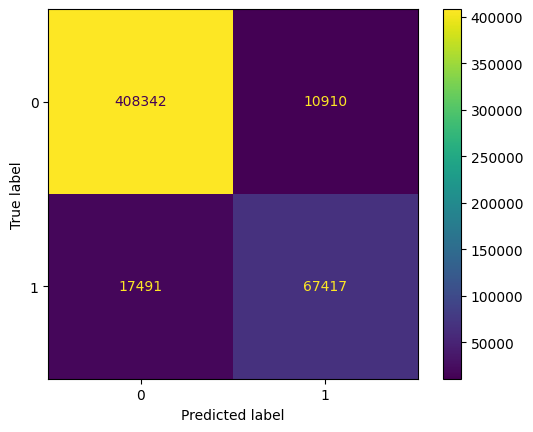

In [15]:
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

## 5. Random Forest
- Train `RandomForestClassifier` (use unscaled data — tree models don't need scaling)
- Predict labels and probability scores
- Evaluate: Accuracy, Precision, Recall, F1, ROC-AUC
- Plot confusion matrix and ROC curve
- Plot top 15 feature importances

In [ ]:
model_forest  = RandomForestClassifier()
model_forest.fit(X_train, y_train)

predictions_forest = model_forest.predict(X_test)
probabilities_forest = model_forest.predict_proba(X_test)


              precision    recall  f1-score   support

           0       0.96      0.97      0.97    419252
           1       0.86      0.79      0.83     84908

    accuracy                           0.94    504160
   macro avg       0.91      0.88      0.90    504160
weighted avg       0.94      0.94      0.94    504160


Accuracy: 0.9437
ROC-AUC:  0.9781


In [20]:
accuracy_forest = accuracy_score(y_test, predictions_forest)
roc_auc_forest = roc_auc_score(y_test, probabilities_forest[:, 1])

print(classification_report(y_test, predictions_forest, digits=4))
print(f"\nAccuracy: {accuracy_forest:.4f}")
print(f"ROC-AUC:  {roc_auc_forest:.4f}")

              precision    recall  f1-score   support

           0     0.9991    0.9993    0.9992    419252
           1     0.9965    0.9954    0.9959     84908

    accuracy                         0.9986    504160
   macro avg     0.9978    0.9973    0.9975    504160
weighted avg     0.9986    0.9986    0.9986    504160


Accuracy: 0.9986
ROC-AUC:  0.9998


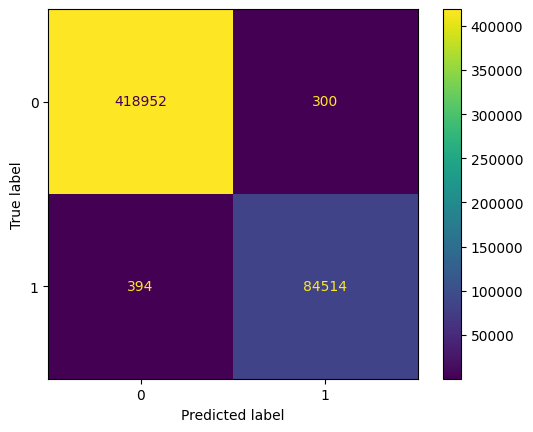

In [21]:
cm_forest = confusion_matrix(y_test, predictions_forest)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_forest)
disp.plot()

In [23]:
def plot_feature_importance(model, feature_names, title, n=20):
    importances = pd.Series(model.feature_importances_, index=feature_names)
    importances.nlargest(n).sort_values().plot(kind='barh')
    plt.title(title)
    plt.tight_layout()
    plt.show()

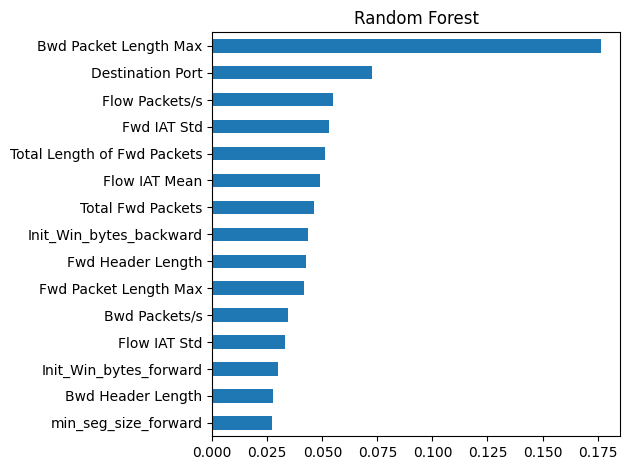

In [24]:
plot_feature_importance(model_forest, X_train.columns, "Random Forest", n=15)

## 6. XGBoost
- Train `XGBClassifier` (use unscaled data)
- Predict labels and probability scores
- Evaluate: Accuracy, Precision, Recall, F1, ROC-AUC
- Plot confusion matrix and ROC curve
- Plot top 15 feature importances

In [25]:
model_xgb  = GradientBoostingClassifier()
model_xgb.fit(X_train, y_train)

predictions_xgb = model_xgb.predict(X_test)
probabilities_xgb = model_xgb.predict_proba(X_test)

In [26]:
accuracy_xgb = accuracy_score(y_test, predictions_xgb)
roc_auc_xgb = roc_auc_score(y_test, probabilities_xgb[:, 1])

print(classification_report(y_test, predictions_xgb, digits=4))
print(f"\nAccuracy: {accuracy_xgb:.4f}")
print(f"ROC-AUC:  {roc_auc_xgb:.4f}")

              precision    recall  f1-score   support

           0     0.9963    0.9989    0.9976    419252
           1     0.9944    0.9816    0.9879     84908

    accuracy                         0.9960    504160
   macro avg     0.9953    0.9902    0.9928    504160
weighted avg     0.9960    0.9960    0.9960    504160


Accuracy: 0.9960
ROC-AUC:  0.9992


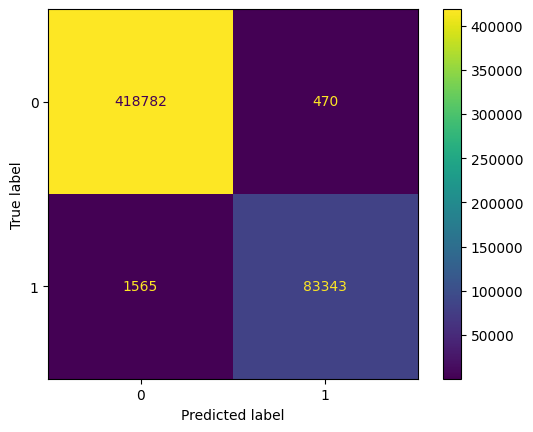

In [27]:
cm_xgb = confusion_matrix(y_test, predictions_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp.plot()

## 7. SVM
- Train `SVC(probability=True)` on scaled data
- **Note:** SVM is slow on large datasets — consider training on a stratified sample (e.g. 10-20% of data) if runtime is too long
- Predict labels and probability scores
- Evaluate: Accuracy, Precision, Recall, F1, ROC-AUC
- Plot confusion matrix and ROC curve

In [ ]:
# svm here

## 8. RF + XGBoost Ensemble
- Combine RF and XGBoost using `VotingClassifier(voting='soft')` (averages probability outputs)
- Evaluate: Accuracy, Precision, Recall, F1, ROC-AUC
- Plot confusion matrix and ROC curve

In [ ]:
# ensemble here

## 9. Model Comparison
- Summarize all models in a single comparison table (Accuracy, Precision, Recall, F1, ROC-AUC)
- Plot ROC curves for all models on the same chart
- Identify best performing model → this model's probability scores feed into the risk scoring layer

In [ ]:
# model comparison here

## 10. Save Best Model
- Save the best performing model to disk using `joblib` so it can be loaded in the risk scoring notebook

In [ ]:
# save model with joblib here